# Exploring Chemical Space
Explore some clustering and visualisation models and compare them for two different datasets:
- A subset of ChEMBL small molecule entries with a molecular weight between 200 and 500. Since the entire set of ChEMBL entries is quite substantial, 10k entries were selected by random sampling (`chembl_200-500_10k`)
- The result of the PubChem search for "antibiotics" (`pubchem_antibiotics`).

Note: The ChEMBL dataset may still take quite some processing time - depending on your PC. You can do a random sampling of e.g. 3k entries in order to reduce the computational effort.

Tasks:
1) Load and inspect the two datasets `ChEMBL_200-500_10k.csv`. Note that they are fundamentally different.
2) Perform basic data cleaning and be mindful of which data to dismiss (if any). Hint: Think about standardising column names (at least for the relevant ones)
3) Make sure that the SMILES strings are valid - implement a function to clean up the SMILES returning (in a new column or Series) the canonical SMILES if the input is valid, and return `None` if the SMILES in the original data is not valid (). Hint: The `Normalizer` in  rdkit might be quite useful (https://www.rdkit.org/docs/cppapi/classRDKit_1_1MolStandardize_1_1Normalizer.html)
4) Calculate Morgan Fingerprints (radius 2, 2048 bit) from the SMILES strings via mol objects. Make sure not to use the outdated version. You can use either the dataframe, numpy arrays or simple lists for the fingerprints.
5) Run different clustering techniques, e.g. snippets provided for Butina and HDBSCAN. You can also try the scikit-learn models kmeans or dbscan.
6) Use the fingerprints to run UMAP and TSNE dimensionality reductions (snippets provided).
7) Plot the data in scatterplots, using the cluster labels as colour map.
8) Adjust some parameters of the clustering models and apply filters if needed (e.g. only visualise clusters of a size larger than 10) to reach some satisfactory result
9) Visualise a representative molecule (e.g. centroids or centers of clusters, or random :) ) of the three largest clusters for both methods using rdkit
10) Respond to the discussion points


Import dependencies and datasets

In [1]:
# complete imports if needed for your solution
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from rdkit import Chem
from rdkit.Chem.MolStandardize.rdMolStandardize import Normalizer
from rdkit.Chem import rdFingerprintGenerator
from rdkit import DataStructs
from rdkit.ML.Cluster import Butina
from rdkit.Chem import Draw

from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
import hdbscan
import umap
from sklearn.manifold import TSNE
from rdkit import RDLogger

In [2]:
df1 = pd.read_csv("chembl_200-500_10k.csv")
df_antibiotics = pd.read_csv("pubchem_antibiotics.csv")

In [3]:
#choose random 3000 rows
df_chembl = df1.sample(n=3000, random_state=42).reset_index(drop=True)
df_chembl.head()

,ChEMBL ID,Name,Synonyms,Type,Max Phase,Molecular Weight,Targets,Bioactivities,AlogP,Polar Surface Area,...,Heavy Atoms,Np Likeness Score,Molecular Formula,SMILES,Inchi Key,Inchi,Withdrawn Flag,Orphan,Records Key,Records Name
0,CHEMBL4080795,NaN,NaN,Small molecule,NaN,332.28,2.0,11.0,2.98,59.06,...,24.0,-1.29,C17H11F3N2O2,O=c1c(NCc2ccccn2)c(-c2ccc(C(F)(F)F)cc2)c1=O,JYWSWFXMMJXOQM-UHFFFAOYSA-N,"InChI=1S/C17H11F3N2O2/c18-17(19,20)11-6-4-10(5...",False,-1,"['31c', '104']",['3-(Pyridin-2-ylmethylamino)-4-(4-(trifluorom...
1,CHEMBL2110942,NELEZAPRINE,NELEZAPRINA|NELEZAPRINE,Small molecule,2.0,300.83,NaN,NaN,4.08,8.17,...,21.0,-0.74,C18H21ClN2,CN(C)CC/C=C1\c2cc(Cl)ccc2CCn2cccc21,HOVKCSFHZRYZBX-FZSIALSZSA-N,InChI=1S/C18H21ClN2/c1-20(2)10-3-5-16-17-13-15...,False,0,['NELEZAPRINE'],['NELEZAPRINE']
2,CHEMBL370979,NaN,NaN,Small molecule,NaN,322.35,1.0,3.0,0.71,147.84,...,22.0,0.67,C11H14N8O2S,CSC[C@H]1O[C@@H](n2cnc3c(N)ncnc32)C(N=[N+]=[N-...,VBZWFEMCJOZUPI-RNNYNIFOSA-N,InChI=1S/C11H14N8O2S/c1-22-2-5-8(20)6(17-18-13...,False,-1,['6'],"['(2S,3S,5R)-5-(6-Amino-purin-9-yl)-4-azido-2-..."
3,CHEMBL527159,NaN,NaN,Small molecule,NaN,484.99,6.0,9.0,1.88,91.85,...,33.0,-1.22,C24H29ClN6O3,COc1ccc2nccc(N3CCN(CCNCc4ccc5c(n4)NC(=O)CO5)CC...,BZLIQUXHYZJETN-UHFFFAOYSA-N,InChI=1S/C24H28N6O3.ClH/c1-32-18-3-4-20-19(14-...,False,-1,"['TCMDC-141961', 'TCMDC-141961']","[None, 'TCMDC-141961']"
4,CHEMBL3274012,NaN,NaN,Small molecule,NaN,333.87,1.0,4.0,2.79,45.98,...,22.0,-1.61,C17H24ClN5,Cc1nn(C)c2nc3ccccc3c(NCCCN(C)C)c12.Cl,QISVAUVVDXVIPC-UHFFFAOYSA-N,InChI=1S/C17H23N5.ClH/c1-12-15-16(18-10-7-11-2...,False,-1,"['1, BL-20803']","['N1-(1,3-dimethyl-1H-pyrazolo[3,4-b]quinolin-..."


In [4]:
df_antibiotics.head()

,Compound_CID,Name,Synonyms,Molecular_Formula,InChI,Smiles,InChIKey,IUPAC_Name,MeSH_Headings,Annotation_Content,...,Defined_Atom_Stereo_Count,Undefined_Atom_Stereo_Count,Total_Bond_Stereo_Count,Defined_Bond_Stereo_Count,Undefined_Bond_Stereo_Count,Linked_PubChem_Literature_Count,Linked_PubChem_Patent_Count,Linked_PubChem_Patent_Family_Count,Annotation_Type_Count,Create_Date
0,16131155,Antibiotic A 47934,A-47934 Antibiotic|Antibiotic A 47934|RefChem:...,C58H44Cl3N7O21S,InChI=1S/C58H44Cl3N7O21S/c59-31-7-20-1-4-36(31...,C1[C@@H]2C(=O)N[C@@H](C3=CC(=CC(=C3)OC4=C(C=CC...,HRGFAEUWEMDRRZ-QLRHZSCISA-N,"(1S,2R,19R,22R,34S,37R,40R,52S)-22-amino-5,15,...",antibiotic A 47934,Classification|Literature|Patents|Taxonomy,...,8,0,0,0,0,17,60,13,4,20070703
1,6439108,Antibiotic S 632-B1,Antibiotic S 632-B1|121995-32-2|S632-B1|S632-B...,C17H25NO5,InChI=1S/C17H25NO5/c1-9(4-10(2)17-11(3)23-17)1...,CC1C(O1)/C(=C\C(C)C(=O)CC(CC2CC(=O)NC(=O)C2)O)/C,JEIOGENOOQCFDS-WMZJFQQLSA-N,4-[(Z)-2-hydroxy-5-methyl-7-(3-methyloxiran-2-...,antibiotic S 632-B1,Classification|Literature|Toxicity,...,0,4,1,1,0,3,0,0,3,20060428
2,9690107,Antibiotic FK 089,FK-089 antibiotic|Antibiotic FK 089|86070-74-8...,C14H12N4O7S2,InChI=1S/C14H12N4O7S2/c19-8(20)3-25-17-9(6-4-2...,C1C=C(N2[C@H](S1)[C@@H](C2=O)NC(=O)/C(=N\OCC(=...,YVVLVHFJBQEWHH-NSHRYQRRSA-N,"(6R,7R)-7-[[(2Z)-2-(carboxymethoxyimino)-2-(1,...",antibiotic FK 089,Biological Test Results|Classification|Literat...,...,2,0,1,1,0,2,5,1,4,20061024
3,125607,Antibiotic A447 C,Antibiotic A447 C|95599-38-5|Antibiotic A447-C...,C60H88N2O20,InChI=1S/C60H88N2O20/c1-12-60(70)26-41(79-46-2...,CCC1(CC(C2=C(C1OC3CC(C(C(O3)C)OC4CCC(C(O4)C)OC...,JCVKGZNZMVGUIP-UHFFFAOYSA-N,"7,10-bis[[4-(dimethylamino)-5-[5-(5-hydroxy-6-...",antibiotic A447 C,Classification|Literature,...,0,23,0,0,0,1,0,0,2,20050808
4,5487319,DOB-41 antibiotic,Dob-41 antibiotic|Antibiotic dob 41|115666-98-...,C19H18N2O6,InChI=1S/C19H18N2O6/c1-10(27-19(25)15(9-22)26-...,C[C@H](C1=C2C(=CC=C1)N=C3C(=N2)C=CC=C3C(=O)O)O...,OSEDIRANPWGFRX-MEBBXXQBSA-N,6-[(1R)-1-[(2R)-3-hydroxy-2-methoxypropanoyl]o...,DOB-41 antibiotic,Classification|Literature|Patents,...,2,0,0,0,0,1,5,1,3,20050808


In [5]:
# inspect what columns
print(df_chembl.columns.tolist())
print(df_antibiotics.columns.tolist())

['ChEMBL ID', 'Name', 'Synonyms', 'Type', 'Max Phase', 'Molecular Weight', 'Targets', 'Bioactivities', 'AlogP', 'Polar Surface Area', 'HBA', 'HBD', '#RO5 Violations', '#Rotatable Bonds', 'Passes Ro3', 'QED Weighted', 'Aromatic Rings', 'Structure Type', 'Inorganic Flag', 'Heavy Atoms', 'Np Likeness Score', 'Molecular Formula', 'SMILES', 'Inchi Key', 'Inchi', 'Withdrawn Flag', 'Orphan', 'Records Key', 'Records Name']
['Compound_CID', 'Name', 'Synonyms', 'Molecular_Formula', 'InChI', 'Smiles', 'InChIKey', 'IUPAC_Name', 'MeSH_Headings', 'Annotation_Content', 'Linked_BioAssays', 'Data_Source', 'Data_Source_Category', 'Tagged_by_PubChem', 'Molecular_Weight', 'Polar_Area', 'Complexity', 'XLogP', 'Heavy_Atom_Count', 'H-Bond_Donor_Count', 'H-Bond_Acceptor_Count', 'Rotatable_Bond_Count', 'Exact_Mass', 'Monoisotopic_Mass', 'Charge', 'Covalent_Unit_Count', 'Isotopic_Atom_Count', 'Total_Atom_Stereo_Count', 'Defined_Atom_Stereo_Count', 'Undefined_Atom_Stereo_Count', 'Total_Bond_Stereo_Count', 'Defin

In [6]:
df_antibiotics.isna().sum().sum()


np.int64(4048)

In [7]:
df_chembl.isna().sum().sum()

np.int64(9595)

Data cleaning

In [8]:
#rename smiles columns 
df_chembl      = df_chembl.rename(columns={'SMILES': 'smiles'})
df_antibiotics = df_antibiotics.rename(columns={'Smiles': 'smiles'})
# rename feature columns to be the same
df_chembl = df_chembl.rename(columns={
    'Molecular Weight'  : 'MWT',
    'AlogP'             : 'logp',
    'Polar Surface Area': 'tpsa',
    'HBA': 'hba', 'HBD': 'hbd',
})
df_antibiotics = df_antibiotics.rename(columns={
    'Molecular_Weight'     : 'MWT',
    'XLogP'                : 'logp',
    'Polar_Area'           : 'tpsa',
    'H-Bond_Acceptor_Count': 'hba',
    'H-Bond_Donor_Count'   : 'hbd',
})

#choose only the columns we need
df_chembl = df_chembl[['smiles', 'MWT', 'logp', 'tpsa', 'hba', 'hbd']]
df_antibiotics = df_antibiotics[['smiles', 'MWT', 'logp', 'tpsa', 'hba', 'hbd']]


In [9]:
print(df_chembl.columns.tolist())
print(df_antibiotics.columns.tolist())

['smiles', 'MWT', 'logp', 'tpsa', 'hba', 'hbd']
['smiles', 'MWT', 'logp', 'tpsa', 'hba', 'hbd']


In [10]:
df_chembl.dropna(subset=['smiles',"MWT"], inplace=True)
df_antibiotics.dropna(subset=['smiles',"MWT"], inplace=True)

In [11]:
df_chembl.isna().sum()

smiles     0
MWT        0
logp      15
tpsa      15
hba       15
hbd       15
dtype: int64

In [12]:
df_chembl.drop_duplicates(subset=['smiles'], inplace=True)
df_antibiotics.drop_duplicates(subset=['smiles'], inplace=True)

In [13]:
RDLogger.DisableLog('rdApp.*') #suppress RDKit warnings about invalid SMILES etc.


normalizer = Normalizer()

def get_canonical_smiles(smiles):
    """
    Parse, normalise and canonicalise a SMILES string.
    Returns canonical SMILES if valid, None if invalid.
    """
    if not isinstance(smiles, str) or smiles.strip() == '':
        return None

    # Step 1: parse raw SMILES → mol object
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None          # invalid SMILES → discard

    # Step 2: normalise (fixes non-standard representations)
    mol = normalizer.normalize(mol)

    # Step 3: return canonical SMILES string
    return Chem.MolToSmiles(mol)


df_chembl['canonical_smiles']      = df_chembl['smiles'].apply(get_canonical_smiles)
df_antibiotics['canonical_smiles'] = df_antibiotics['smiles'].apply(get_canonical_smiles)

Calculate Morgan Fingerprints (`GetMorganGenerator`). You can experiment with other fingerprints (`GetRDKitFPGenerator`) as well and see how they impact the clusters.

In [14]:
morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)

def get_fingerprint(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    return morgan_gen.GetFingerprint(mol)

df_chembl['fp_morgan']      = df_chembl['canonical_smiles'].apply(get_fingerprint)
df_antibiotics['fp_morgan'] = df_antibiotics['canonical_smiles'].apply(get_fingerprint)


In [15]:
rdkit_gen  = rdFingerprintGenerator.GetRDKitFPGenerator(fpSize=2048)

df_chembl['fp_rdkit']      = df_chembl['canonical_smiles'].apply(
    lambda x: rdkit_gen.GetFingerprint(Chem.MolFromSmiles(x)))
df_antibiotics['fp_rdkit'] = df_antibiotics['canonical_smiles'].apply(
    lambda x: rdkit_gen.GetFingerprint(Chem.MolFromSmiles(x)))

In [16]:
df_chembl.head()

,smiles,MWT,logp,tpsa,hba,hbd,canonical_smiles,fp_morgan,fp_rdkit
0,O=c1c(NCc2ccccn2)c(-c2ccc(C(F)(F)F)cc2)c1=O,332.28,2.98,59.06,4.0,1.0,O=c1c(NCc2ccccn2)c(-c2ccc(C(F)(F)F)cc2)c1=O,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, ..."
1,CN(C)CC/C=C1\c2cc(Cl)ccc2CCn2cccc21,300.83,4.08,8.17,2.0,0.0,CN(C)CC/C=C1\c2cc(Cl)ccc2CCn2cccc21,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, ..."
2,CSC[C@H]1O[C@@H](n2cnc3c(N)ncnc32)C(N=[N+]=[N-...,322.35,0.71,147.84,9.0,2.0,CSC[C@H]1O[C@@H](n2cnc3c(N)ncnc32)C(N=[N+]=[N-...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, ..."
3,COc1ccc2nccc(N3CCN(CCNCc4ccc5c(n4)NC(=O)CO5)CC...,484.99,1.88,91.85,8.0,2.0,COc1ccc2nccc(N3CCN(CCNCc4ccc5c(n4)NC(=O)CO5)CC...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, ..."
4,Cc1nn(C)c2nc3ccccc3c(NCCCN(C)C)c12.Cl,333.87,2.79,45.98,5.0,1.0,Cc1nn(C)c2nc3ccccc3c(NCCCN(C)C)c12.Cl,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, ..."


Butina Clustering: Investigate later how different cutoffs for the similarity affect the clusters.

In [17]:
#Morgan fingerprints as list for clustering

fp_list_chembl = df_chembl['fp_morgan'].tolist()

# Butina clustering requires distance matrix (distance = Tanimoto similarity); 
# fingerprints provided as list in this snippet - adjust as needed!
dists = []
nfps = len(fp_list_chembl)

for i in range(1, nfps): #compare molecule i to all previous molecules (0 to i-1)
    similarities = DataStructs.BulkTanimotoSimilarity(fp_list_chembl[i], fp_list_chembl[:i])
    dists.extend([1-x for x in similarities])

# Apply Butina Clustering

# Apply different thresholds later and see how they affect the clustering
cutoff = 0.6  # Tanimoto similarity threshold; e.g. 04 for larger chemical families, 0.7 for tight analogues...

butina_clusters = Butina.ClusterData(
    dists, # similarity based distance matrix
    nfps, # number of fingerprints
    cutoff,
    isDistData=True
)

print("Number of clusters using morgan fp:", len(butina_clusters))

Number of clusters using morgan fp: 2554


In [18]:
def run_butina(fp_list, cutoff=0.6, min_cluster_size=10):
    """Run Butina clustering on a list of fingerprints."""
    dists = []
    nfps  = len(fp_list)

    for i in range(1, nfps):
        similarities = DataStructs.BulkTanimotoSimilarity(fp_list[i], fp_list[:i])
        dists.extend([1-x for x in similarities])

    clusters = Butina.ClusterData(dists, nfps, cutoff, isDistData=True)
    filtered = [c for c in clusters if len(c) >= min_cluster_size]

    labels = np.full(nfps, -1)
    for cluster_id, cluster in enumerate(filtered):
        for idx in cluster:
            labels[idx] = cluster_id

    sizes = [len(c) for c in filtered]
    print(f"  Clusters:    {len(filtered)}")
    print(f"  Mean size:   {np.mean(sizes):.1f}")
    print(f"  Max size:    {np.max(sizes)}")
    print(f"  Singletons:  {sum(s == 1 for s in sizes)}")
    return clusters, filtered, labels


print("Butina ChEMBL — Morgan:")
_, clusters_filtered_chembl, butina_labels_chembl = run_butina(
    df_chembl['fp_morgan'].tolist(), cutoff=0.6)

print("\nButina Antibiotics — Morgan:")
_, clusters_filtered_antibiotics, butina_labels_antibiotics = run_butina(
    df_antibiotics['fp_morgan'].tolist(), cutoff=0.6)

Butina ChEMBL — Morgan:
  Clusters:    1
  Mean size:   10.0
  Max size:    10
  Singletons:  0

Butina Antibiotics — Morgan:
  Clusters:    48
  Mean size:   28.4
  Max size:    125
  Singletons:  0


In [19]:
# ChemBL — RDKit
print("Butina ChEMBL — RDKit:")
_, clusters_filtered_chembl_rdkit, butina_labels_chembl_rdkit = run_butina(
    df_chembl['fp_rdkit'].tolist(), cutoff=0.6)

# Antibiotics — RDKit
print("\nButina Antibiotics — RDKit:")
_, clusters_filtered_antibiotics_rdkit, butina_labels_antibiotics_rdkit = run_butina(
    df_antibiotics['fp_rdkit'].tolist(), cutoff=0.6)


Butina ChEMBL — RDKit:
  Clusters:    18
  Mean size:   95.8
  Max size:    1442
  Singletons:  0

Butina Antibiotics — RDKit:
  Clusters:    7
  Mean size:   297.6
  Max size:    1963
  Singletons:  0


In [20]:
#results summary table
results = []

for dataset_name, df in [('ChEMBL', df_chembl), ('Antibiotics', df_antibiotics)]:
    for fp_name in ['fp_morgan', 'fp_rdkit']:
        _, filtered, labels = run_butina(df[fp_name].tolist(), cutoff=0.6)
        sizes = [len(c) for c in filtered]
        results.append({
            'Dataset'   : dataset_name,
            'FP Type'   : fp_name,
            'Clusters'  : len(filtered),
            'Mean Size' : round(np.mean(sizes), 1),
            'Max Size'  : np.max(sizes),
            'Singletons': sum(s == 1 for s in sizes),
            'Noise'     : list(labels).count(-1)
        })

results_df = pd.DataFrame(results)
results_df

  Clusters:    1
  Mean size:   10.0
  Max size:    10
  Singletons:  0
  Clusters:    18
  Mean size:   95.8
  Max size:    1442
  Singletons:  0
  Clusters:    48
  Mean size:   28.4
  Max size:    125
  Singletons:  0
  Clusters:    7
  Mean size:   297.6
  Max size:    1963
  Singletons:  0


,Dataset,FP Type,Clusters,Mean Size,Max Size,Singletons,Noise
0,ChEMBL,fp_morgan,1,10.0,10,0,2988
1,ChEMBL,fp_rdkit,18,95.8,1442,0,1274
2,Antibiotics,fp_morgan,48,28.4,125,0,992
3,Antibiotics,fp_rdkit,7,297.6,1963,0,273


In [21]:
#already done above!!!

# filter out small clusters, rare chemoptypes, ...
clusters_filtered = [c for c in butina_clusters if len(c) >= 10]

butina_labels = np.full(nfps, -1)
for cluster_id, cluster in enumerate(clusters_filtered):
    for id in cluster:
        butina_labels[id] = cluster_id

sizes = [len(c) for c in clusters_filtered]

print("clusters:", len(sizes))
print("mean size:", np.mean(sizes))
print("max size:", np.max(sizes))
print("singletons:", sum(s == 1 for s in sizes))

clusters: 1
mean size: 10.0
max size: 10
singletons: 0


HDBSCAN Clustering: Inspect how `min_cluster_size` and `min_samples` affect the clusters later on. This might depend quite a lot on the dataset (try 15 and 5 for the PubChem data, <10 and <5 for the ChEMBL)

In [33]:
def fps_to_numpy(fp_list):
    X = np.zeros((len(fp_list), 2048), dtype=np.uint8)
    for i, fp in enumerate(fp_list):
        DataStructs.ConvertToNumpyArray(fp, X[i])
    return X

X_chembl_morgan      = fps_to_numpy(df_chembl['fp_morgan'].tolist())
X_antibiotics_morgan = fps_to_numpy(df_antibiotics['fp_morgan'].tolist())

print(f"X_chembl_morgan shape:      {X_chembl_morgan.shape}")
print(f"X_antibiotics_morgan shape: {X_antibiotics_morgan.shape}")

X_chembl_morgan shape:      (2998, 2048)
X_antibiotics_morgan shape: (2356, 2048)


In [38]:
# HDBSCAN ChEMBL
hdbs_clustering_chembl = hdbscan.HDBSCAN(
    min_cluster_size=10,
    min_samples=2,
    metric="euclidean"
)
hdbs_labels_chembl = hdbs_clustering_chembl.fit_predict(X_chembl_morgan)


#  HDBSCAN Antibiotics 
hdbs_clustering_antibiotics = hdbscan.HDBSCAN(
    min_cluster_size=15,
    min_samples=5,
    metric="euclidean"
)
hdbs_labels_antibiotics = hdbs_clustering_antibiotics.fit_predict(X_antibiotics_morgan)


In [39]:
print("\nusing Morgan FP:")
print("Number of DBSCAN clusters:",
      len(set(hdbs_labels_chembl)) - (1 if -1 in hdbs_labels_chembl else 0))
print("Noise points:", list(hdbs_labels_chembl).count(-1))

print("\nusing Morgan FP:")
print("Number of DBSCAN clusters:",
      len(set(hdbs_labels_antibiotics)) - (1 if -1 in hdbs_labels_antibiotics else 0))
print("Noise points:", list(hdbs_labels_antibiotics).count(-1))


using Morgan FP:
Number of DBSCAN clusters: 3
Noise points: 2900

using Morgan FP:
Number of DBSCAN clusters: 31
Noise points: 1311


Embeddings: TSNE and UMAP

In [ ]:
# convert fingerprints to numpy
X = np.zeros((nfps, 2048), dtype=int)
for i, fp in enumerate(fp_list):
    DataStructs.ConvertToNumpyArray(fp, X[i])

In [42]:
import warnings
warnings.filterwarnings('ignore')


# Dimensionality reduction by TSNE


umap_model = umap.UMAP(
    n_neighbors=25,
    min_dist=0.2,
    metric="jaccard",
    random_state=42
)
#umap chembl_morgan
umap_chembl = umap_model.fit_transform(X_chembl_morgan)
#umap antibiotics_morgan
umap_antibiotics = umap_model.fit_transform(X_antibiotics_morgan)


In [43]:
# Dimensionality reduction by TSNE
tsne_model = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=42
)


tsne_chembl = tsne_model.fit_transform(X_chembl_morgan)
tsne_antibiotics = tsne_model.fit_transform(X_antibiotics_morgan)

In [44]:
print(umap_chembl.shape)
print(umap_antibiotics.shape)
print(tsne_chembl.shape)
print(tsne_antibiotics.shape)

(2998, 2)
(2356, 2)
(2998, 2)
(2356, 2)


Visualise the two clustering methods in the two embeddings (e.g. as subplot). Make sure to label the axes properly.

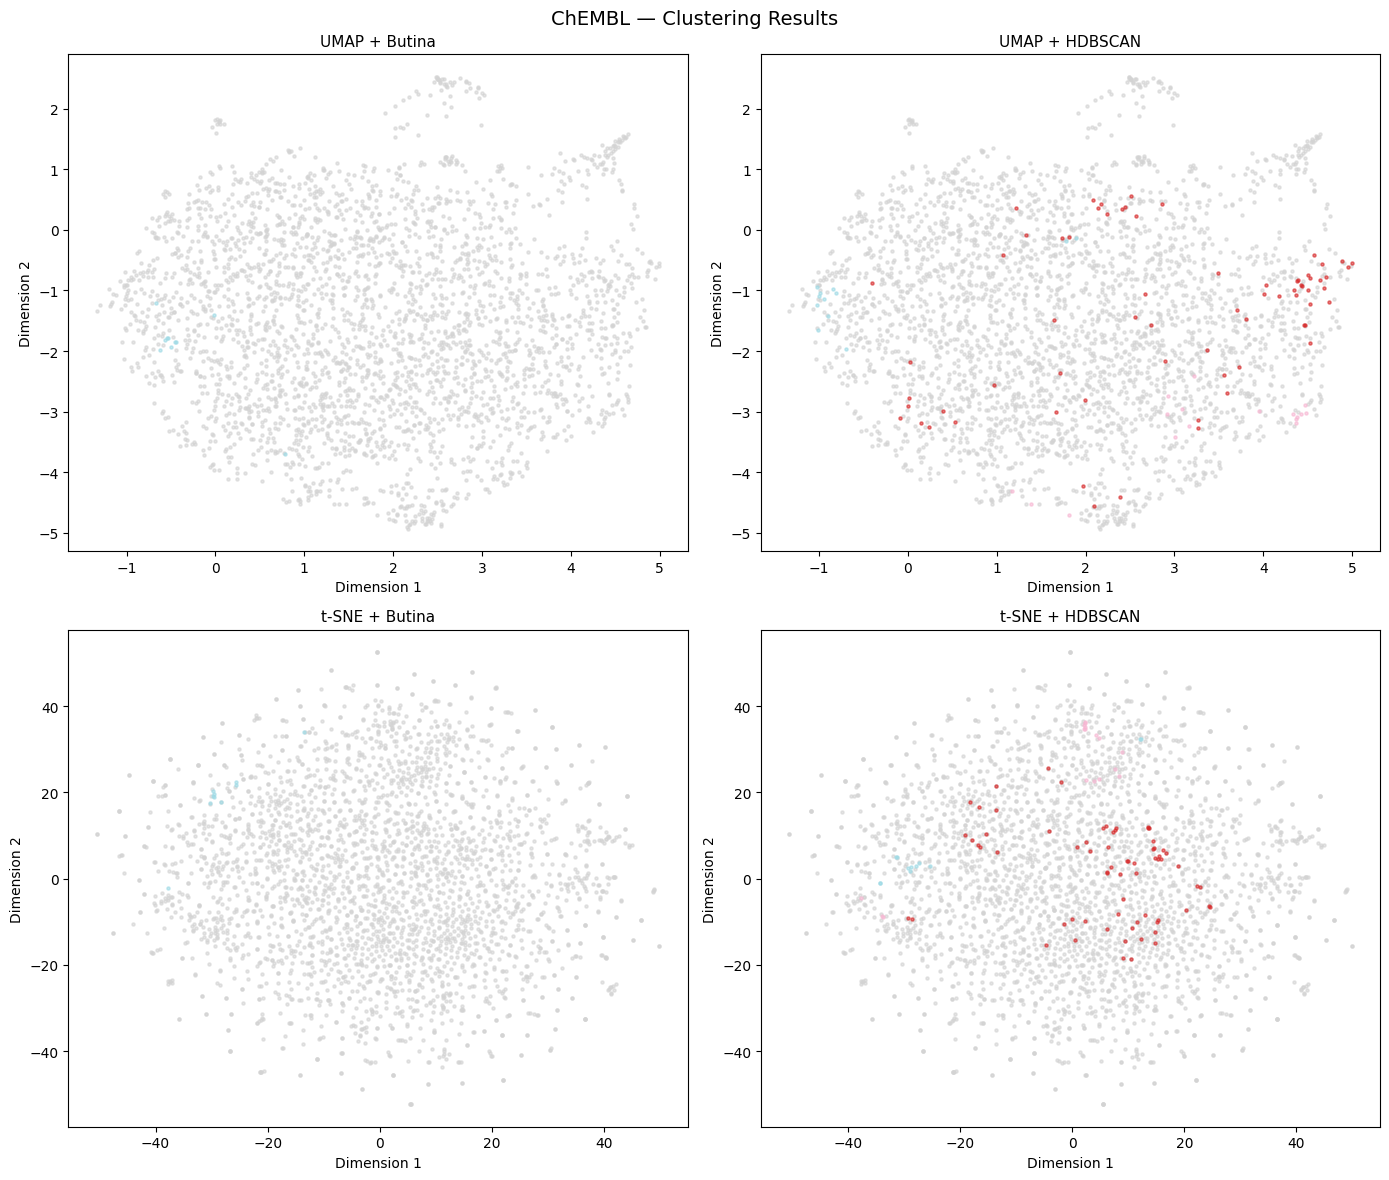

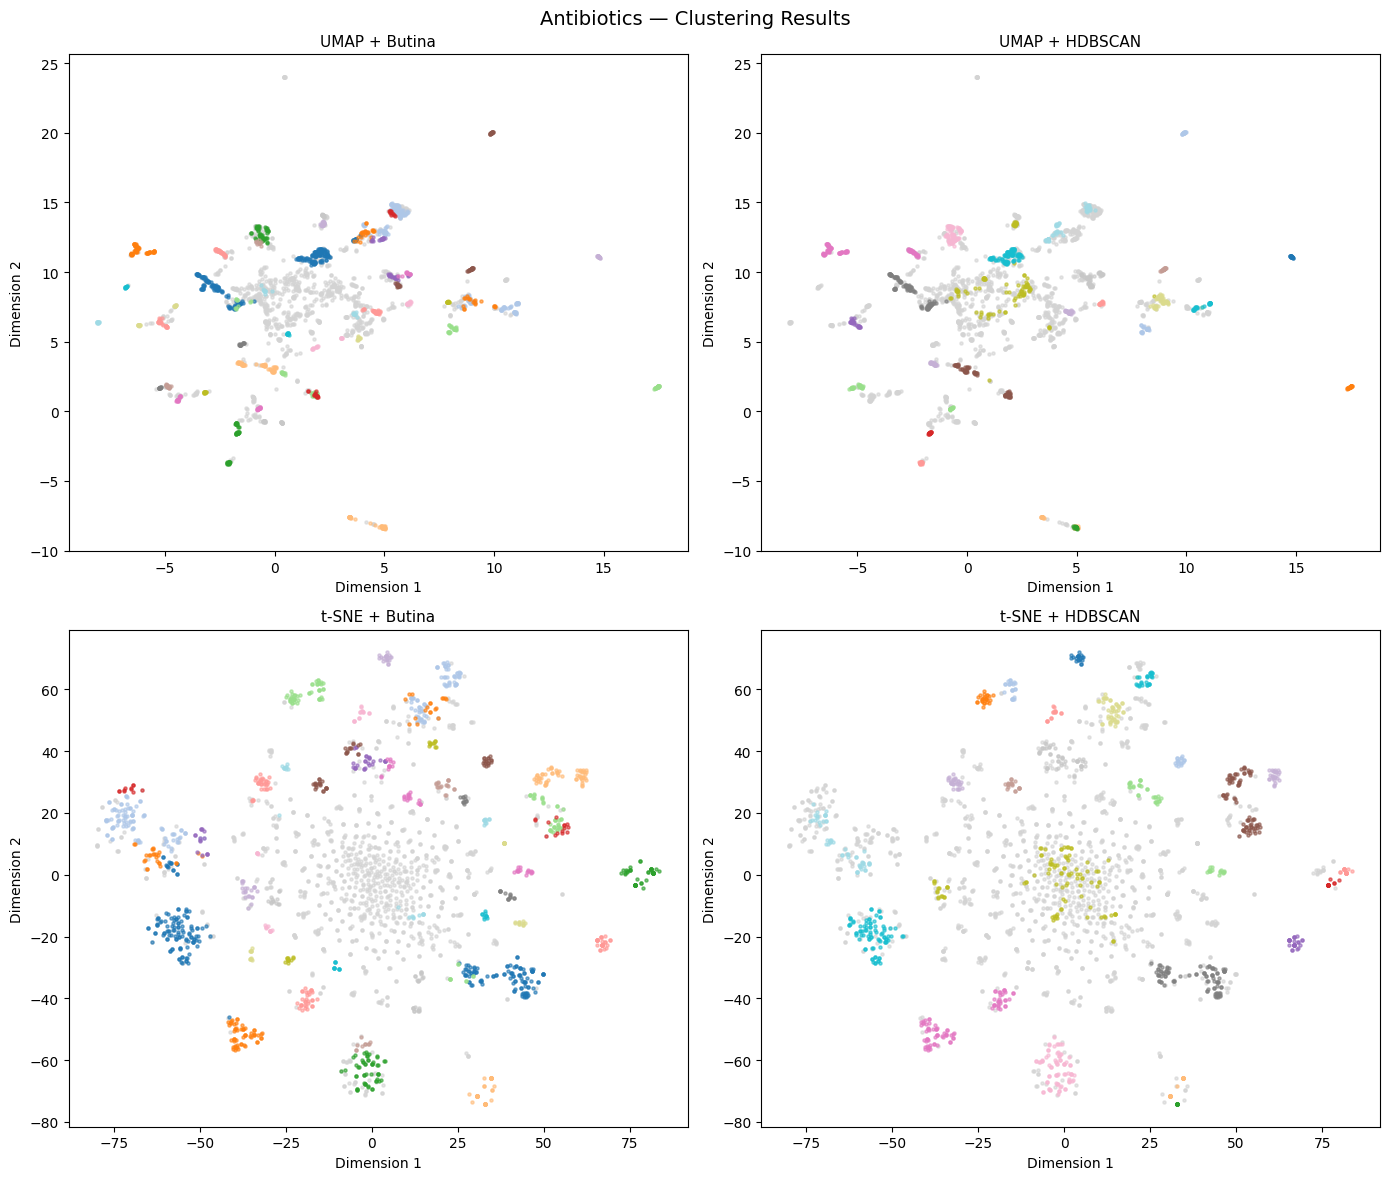

In [49]:


def plot_clusters(embedding, labels, title, ax):
    """Plot 2D embedding coloured by cluster labels."""
    unique_labels = sorted(set(labels))
    cmap          = plt.cm.get_cmap('tab20', len(unique_labels))

    for i, label in enumerate(unique_labels):
        mask  = labels == label
        color = 'lightgrey' if label == -1 else cmap(i)
        name  = 'Noise' if label == -1 else f'Cluster {label}'
        ax.scatter(embedding[mask, 0], embedding[mask, 1],
                   c=[color], s=5, label=name, alpha=0.6)

    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Dimension 1')
    ax.set_ylabel('Dimension 2')

# ChEMBL

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle('ChEMBL — Clustering Results', fontsize=14)

plot_clusters(umap_chembl, butina_labels_chembl,  'UMAP + Butina',   axes[0, 0])
plot_clusters(umap_chembl, hdbs_labels_chembl,    'UMAP + HDBSCAN',  axes[0, 1])
plot_clusters(tsne_chembl, butina_labels_chembl,  't-SNE + Butina',  axes[1, 0])
plot_clusters(tsne_chembl, hdbs_labels_chembl,    't-SNE + HDBSCAN', axes[1, 1])

plt.tight_layout()
plt.show()

# Antibiotics

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle('Antibiotics — Clustering Results', fontsize=14)

plot_clusters(umap_antibiotics, butina_labels_antibiotics,  'UMAP + Butina',   axes[0, 0])
plot_clusters(umap_antibiotics, hdbs_labels_antibiotics,    'UMAP + HDBSCAN',  axes[0, 1])
plot_clusters(tsne_antibiotics, butina_labels_antibiotics,  't-SNE + Butina',  axes[1, 0])
plot_clusters(tsne_antibiotics, hdbs_labels_antibiotics,    't-SNE + HDBSCAN', axes[1, 1])

plt.tight_layout()
plt.show()


Visualise representative molecules of the three biggest clusters of both methods.

## Discussion points
1) What are the characteristics of the chemical spaces described in the two dataset? What is the difference?
2) How do density-based clustering techniques compare to models based on similarity in light of the differences in the datasets?
3) What were the best model parameters for the clustering techniques (i.e. that delivered a meaningful result)
4) Comment on the different dimensionality reduction techniques (again in light of the different dataset characteristics)
5) What was the best / most meaningful combination of dimensionality reduction and clustering methods?
6) Comment on some cheminformatics modelling challenges you may have encountered (e.g. runtime, singleton clusters, paramtersensitivity). What could be done to work around a large number of clusters of small size?
7) On the antibiotics dataset, can you identify some known antibiotic classes / motives in your clusters?
